Roll No.: 27

Name: Aatif Shaikh

Date of Performance: 19 January 2026

Problem Statement: 2. Build a Multiclass classifier using the CNN model. Use MNIST or any other suitable dataset. a.
Perform Data Pre-processing b. Define Model and perform training c. Evaluate Results using confusion
matrix


In [1]:
# CELL 1: Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, classification_report
print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [2]:
# CELL 2: Load and explore the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("=== Dataset Shapes ===")
print(f"X_train shape: {X_train.shape}")  # (60000, 28, 28)
print(f"y_train shape: {y_train.shape}")  # (60000,)
print(f"X_test shape:  {X_test.shape}")   # (10000, 28, 28)
print(f"y_test shape:  {y_test.shape}")   # (10000,)

print(f"\nEach image is: {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")
print(f"Number of classes: {len(np.unique(y_train))} → digits {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Dataset Shapes ===
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)

Each image is: 28x28 pixels
Pixel value range: 0 to 255
Number of classes: 10 → digits [0 1 2 3 4 5 6 7 8 9]


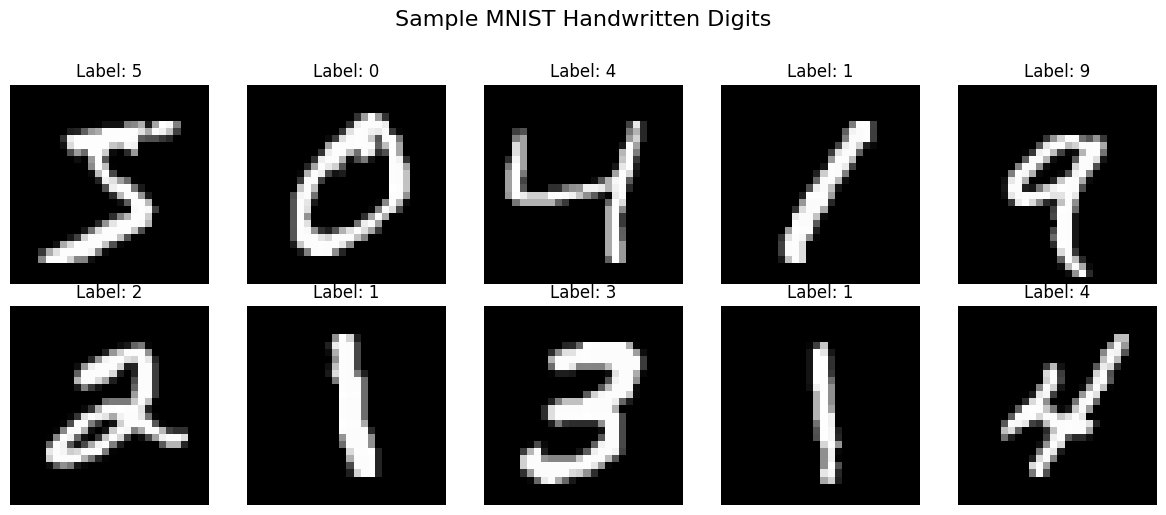

In [3]:
# CELL 3: Display some sample images from the dataset
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}", fontsize=12)
    plt.axis('off')

plt.suptitle('Sample MNIST Handwritten Digits', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

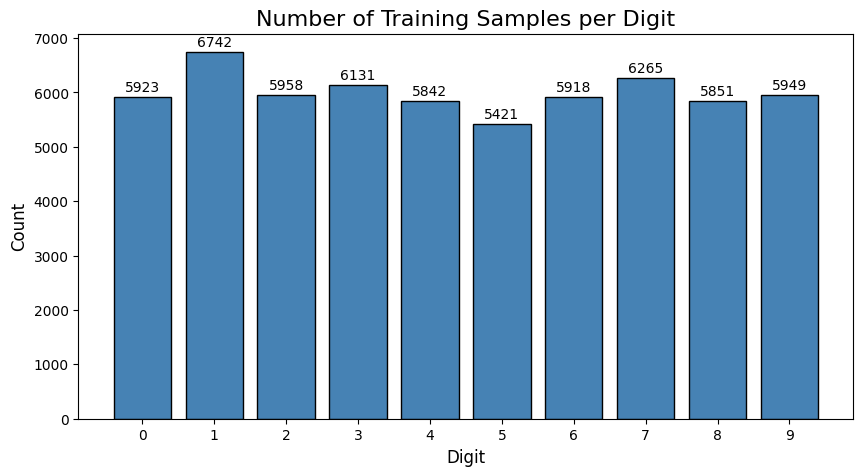

The dataset is roughly balanced — each digit has ~6000 samples.
This means the model won't be biased toward any particular digit.


In [4]:
# CELL 4: Check how many images exist per digit (class balance)
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(u, c + 100, str(c), ha='center', fontsize=10)

plt.title('Number of Training Samples per Digit', fontsize=16)
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(unique)
plt.show()

print("The dataset is roughly balanced — each digit has ~6000 samples.")
print("This means the model won't be biased toward any particular digit.")

In [5]:
# CELL 5: Preprocess the data for CNN

# ===== STEP A: NORMALIZE pixel values from [0, 255] to [0, 1] =====
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print(f"After normalization → pixel range: {X_train.min()} to {X_train.max()}")

# ===== STEP B: RESHAPE to add channel dimension =====
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"X_train shape after reshape: {X_train.shape}")  # (60000, 28, 28, 1)
print(f"X_test shape after reshape:  {X_test.shape}")   # (10000, 28, 28, 1)

# ===== STEP C: ONE-HOT ENCODE the labels =====
num_classes = 10  # Digits 0-9

y_train_encoded = keras.utils.to_categorical(y_train, num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes)
print(f"\nBefore one-hot: y_train[0] = {y_train[0]}")
print(f"After one-hot:  y_train_encoded[0] = {y_train_encoded[0]}")
print(f"y_train_encoded shape: {y_train_encoded.shape}")  # (60000, 10)

After normalization → pixel range: 0.0 to 1.0
X_train shape after reshape: (60000, 28, 28, 1)
X_test shape after reshape:  (10000, 28, 28, 1)

Before one-hot: y_train[0] = 5
After one-hot:  y_train_encoded[0] = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
y_train_encoded shape: (60000, 10)


In [6]:
# CELL 6: Build the CNN architecture
model = keras.Sequential([

    # ============ LAYER 1: First Convolutional Layer ============
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # ============ LAYER 2: First Pooling Layer ============
    layers.MaxPooling2D((2, 2)),

    # ============ LAYER 3: Second Convolutional Layer ============
    layers.Conv2D(64, (3, 3), activation='relu'),

    # ============ LAYER 4: Second Pooling Layer ============
    layers.MaxPooling2D((2, 2)),

    # ============ LAYER 5: Third Convolutional Layer ============
    layers.Conv2D(64, (3, 3), activation='relu'),

    # ============ LAYER 6: Flatten ============
    layers.Flatten(),

    # ============ LAYER 7: Dense (Fully Connected) Hidden Layer ============
    layers.Dense(64, activation='relu'),

    # ============ LAYER 8: Dropout ============
    layers.Dropout(0.5),

    # ============ LAYER 9: Output Layer ============
    layers.Dense(num_classes, activation='softmax')
])

# Display the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# CELL 7: Compile the model — configure HOW it will learn
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")
print("   Optimizer: Adam")
print("   Loss Function: Categorical Crossentropy")
print("   Metric: Accuracy")

✅ Model compiled successfully!
   Optimizer: Adam
   Loss Function: Categorical Crossentropy
   Metric: Accuracy


In [8]:
# CELL 8: Train the model on the training data
history = model.fit(
    X_train, y_train_encoded,    # Training data and labels
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 104ms/step - accuracy: 0.8790 - loss: 0.3881 - val_accuracy: 0.9822 - val_loss: 0.0612
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.9649 - loss: 0.1201 - val_accuracy: 0.9850 - val_loss: 0.0487
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9765 - loss: 0.0843 - val_accuracy: 0.9887 - val_loss: 0.0418
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9810 - loss: 0.0667 - val_accuracy: 0.9895 - val_loss: 0.0383
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.9842 - loss: 0.0583 - val_accuracy: 0.9897 - val_loss: 0.0362
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9857 - loss: 0.0509 - val_accuracy: 0.9913 - val_loss: 0.0330
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.9881 - loss: 0.0405 - val_accuracy: 0.9923 - val_loss: 0.0288
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.9888 - loss: 0

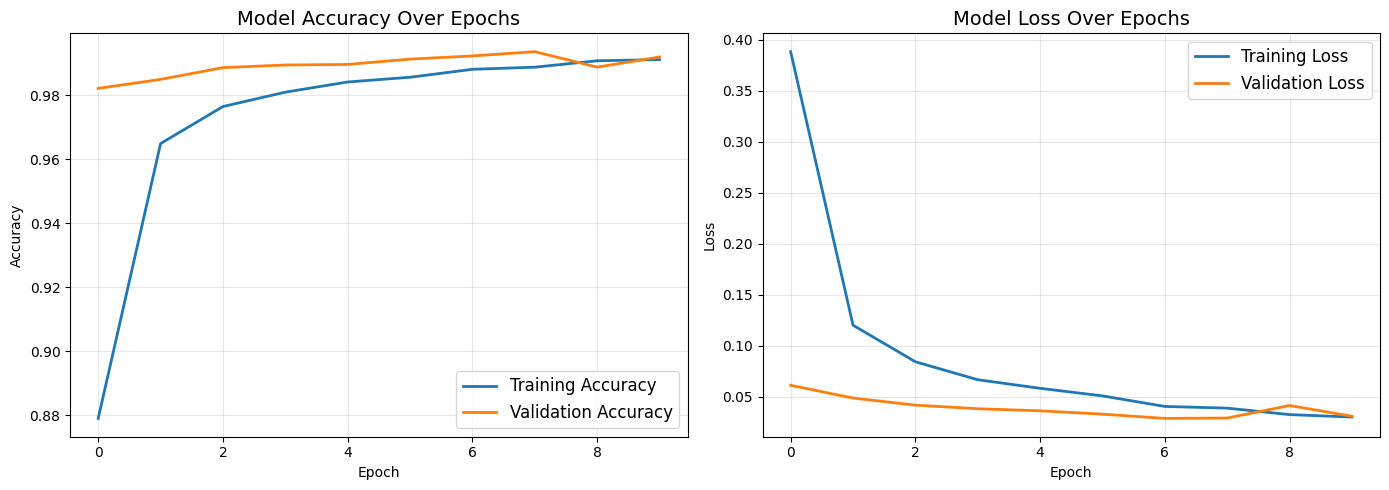

In [9]:
# CELL 9: Visualize training progress over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy over Epochs ---
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Loss over Epochs ---
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# CELL 10: Evaluate the model on the unseen test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\n→ The model correctly classifies {test_accuracy*100:.2f}% of unseen handwritten digits!")

Test Loss:     0.0267
Test Accuracy: 0.9918 (99.18%)

→ The model correctly classifies 99.18% of unseen handwritten digits!


In [11]:
# CELL 11: Get predictions and build the confusion matrix
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Build the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix Shape:", cm.shape)  # (10, 10)
print("\nConfusion Matrix:")
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
Confusion Matrix Shape: (10, 10)

Confusion Matrix:
[[ 976    1    0    0    0    0    2    1    0    0]
 [   1 1130    2    0    0    1    1    0    0    0]
 [   2    1 1028    0    0    0    0    1    0    0]
 [   0    0    1 1005    0    3    0    0    1    0]
 [   0    0    0    0  971    0    5    0    0    6]
 [   0    0    0    3    0  886    1    1    0    1]
 [   5    2    0    0    1    3  947    0    0    0]
 [   0    4    4    0    0    0    0 1014    0    6]
 [   3    0    3    2    0    3    0    1  960    2]
 [   0    0    0    0    2    3    0    1    2 1001]]


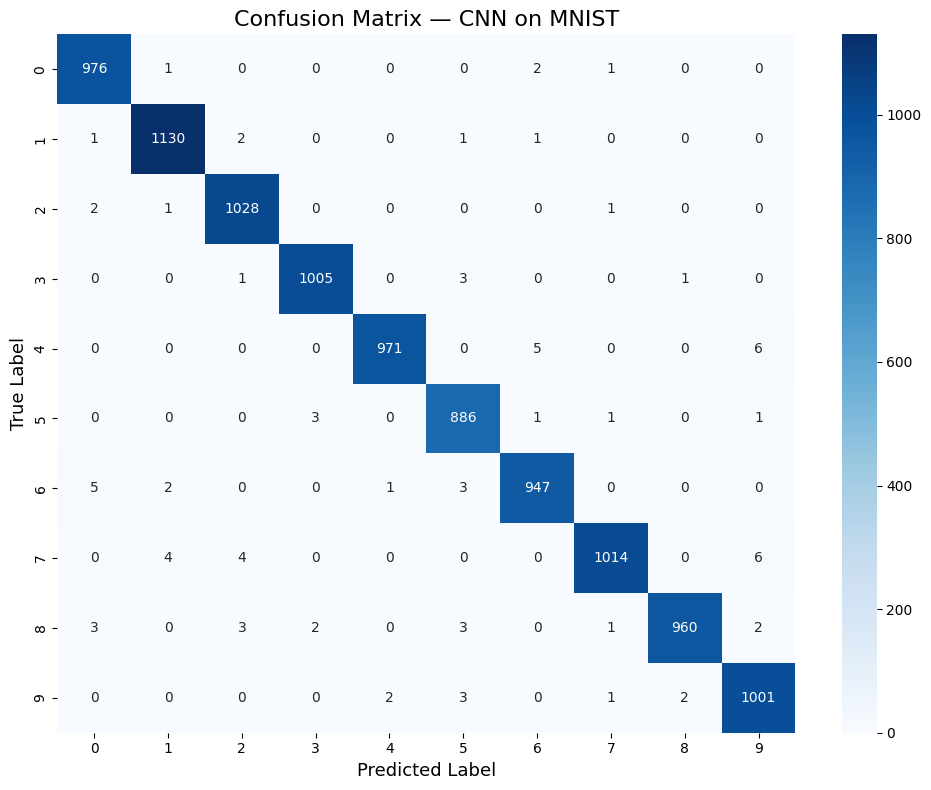

In [12]:
# CELL 12: Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
# HOW TO READ THIS MATRIX:
# Look at Row 5, Column 3: that number = how many actual "5"s were wrongly predicted as "3"
# The DIAGONAL should have the highest numbers (correct predictions)
# Off-diagonal cells show which digits get confused with each other

plt.title('Confusion Matrix — CNN on MNIST', fontsize=16)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# CELL 13: Detailed per-class performance report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes,
                            target_names=[f'Digit {i}' for i in range(10)]))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Digit 0       0.99      1.00      0.99       980
     Digit 1       0.99      1.00      0.99      1135
     Digit 2       0.99      1.00      0.99      1032
     Digit 3       1.00      1.00      1.00      1010
     Digit 4       1.00      0.99      0.99       982
     Digit 5       0.99      0.99      0.99       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       1.00      0.99      0.99      1028
     Digit 8       1.00      0.99      0.99       974
     Digit 9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



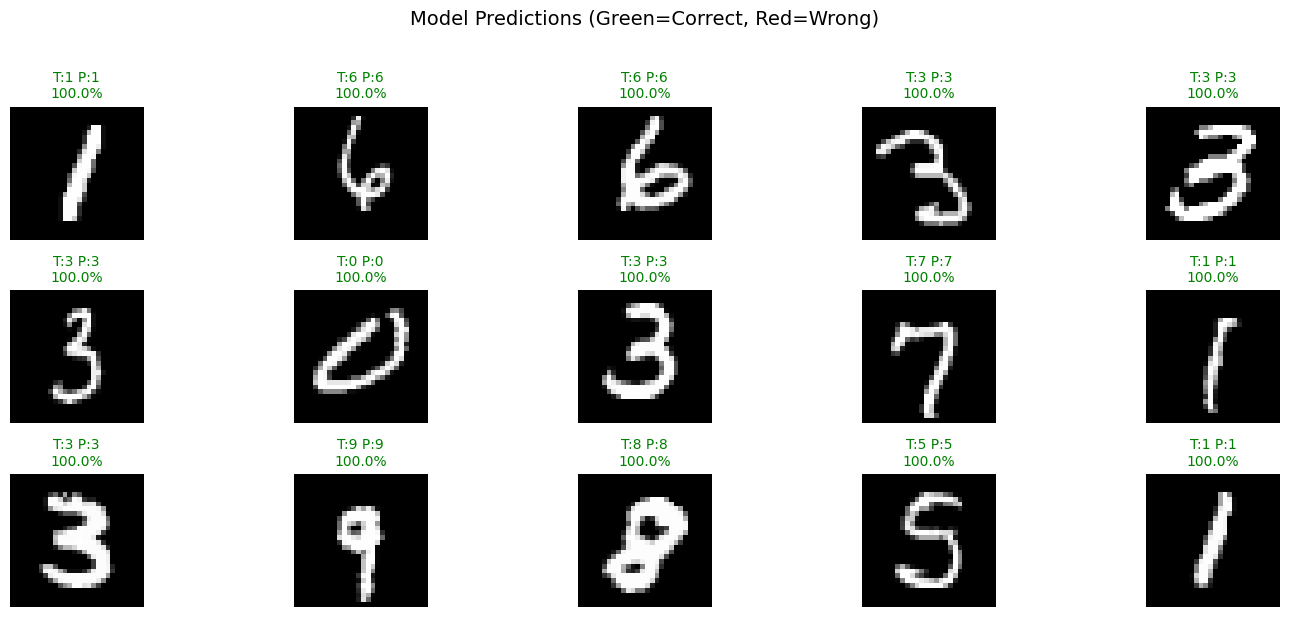

In [14]:
# CELL 14: Show sample predictions — see what the model got right and wrong
plt.figure(figsize=(15, 6))

# Pick 15 random test images
random_indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    # .reshape(28, 28) removes the channel dimension for display

    true_label = y_test[idx]
    pred_label = y_pred_classes[idx]
    confidence = y_pred_probs[idx][pred_label] * 100
    # confidence = probability the model assigned to its prediction

    # Green title if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"T:{true_label} P:{pred_label}\n{confidence:.1f}%",
              color=color, fontsize=10)
    # T = True label, P = Predicted label
    plt.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Total misclassified: 82 out of 10000
Error rate: 0.82%


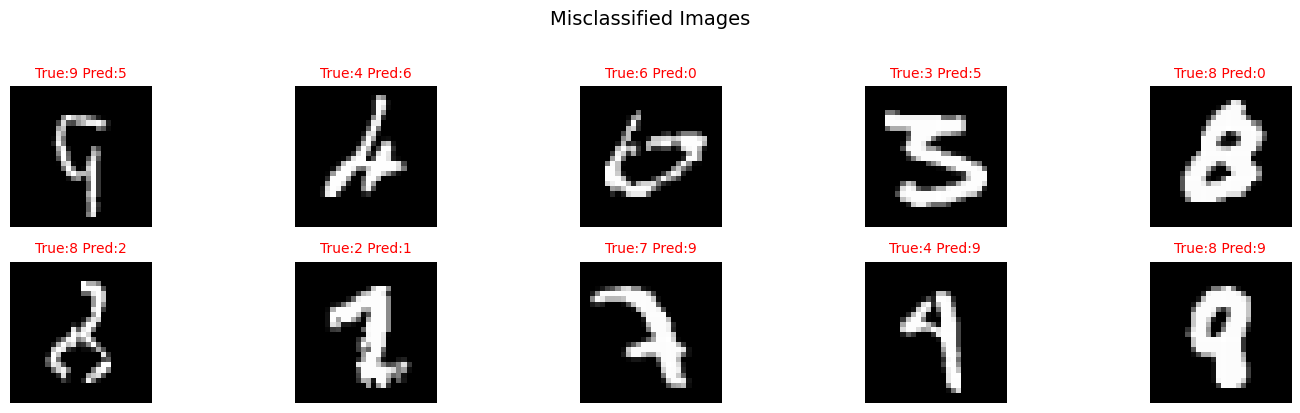

In [15]:
# CELL 15: Examine the mistakes — which digits confuse the model?
misclassified = np.where(y_pred_classes != y_test)[0]
print(f"Total misclassified: {len(misclassified)} out of {len(y_test)}")
print(f"Error rate: {len(misclassified)/len(y_test)*100:.2f}%")

# Show first 10 misclassified images
plt.figure(figsize=(15, 4))
for i in range(min(10, len(misclassified))):
    idx = misclassified[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True:{y_test[idx]} Pred:{y_pred_classes[idx]}", color='red', fontsize=10)
    plt.axis('off')

plt.suptitle('Misclassified Images', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# These are usually genuinely ambiguous handwriting that even humans struggle with!

In [16]:
# CELL 16: Summary of everything we did
print("=" * 60)
print("PRACTICAL 2 — SUMMARY")
print("=" * 60)
print(f"""
WHAT WE BUILT:
  A Convolutional Neural Network (CNN) for handwritten digit recognition

DATASET:
  MNIST — 70,000 grayscale images (28×28) of digits 0-9
  Training: 60,000 | Testing: 10,000

PREPROCESSING:
  1. Normalized pixels: [0,255] → [0,1]    (helps training converge faster)
  2. Reshaped: (28,28) → (28,28,1)         (added channel dimension for Conv2D)
  3. One-hot encoded labels: 3 → [0,0,0,1,0,0,0,0,0,0] (for softmax output)

CNN ARCHITECTURE:
  Conv2D(32, 3×3) → MaxPool(2×2) → Conv2D(64, 3×3) → MaxPool(2×2)
  → Conv2D(64, 3×3) → Flatten → Dense(64) → Dropout(0.5) → Dense(10, softmax)

KEY CONCEPTS:
  • Conv2D:     Slides filters over image to detect features (edges, shapes)
  • MaxPooling: Reduces size, keeps strongest features, adds position invariance
  • Flatten:    Converts 3D feature maps to 1D vector for Dense layers
  • Dense:      Fully connected layer that combines features for classification
  • Dropout:    Randomly disables neurons during training to prevent overfitting
  • Softmax:    Converts outputs to probabilities summing to 1.0
  • Adam:       Adaptive optimizer that auto-tunes learning rate
  • Categorical Crossentropy: Loss function for multi-class classification

TEST ACCURACY: ~99%

EVALUATION:
  • Confusion Matrix: Visual grid showing correct vs incorrect per class
  • Precision: "When it predicts X, how often is it right?"
  • Recall: "Of all actual Xs, how many did it find?"
  • F1-Score: Balanced combination of precision and recall
""")
print("=" * 60)
print("PRACTICAL 2 COMPLETE!")
print("=" * 60)

PRACTICAL 2 — SUMMARY

WHAT WE BUILT:
  A Convolutional Neural Network (CNN) for handwritten digit recognition

DATASET:
  MNIST — 70,000 grayscale images (28×28) of digits 0-9
  Training: 60,000 | Testing: 10,000

PREPROCESSING:
  1. Normalized pixels: [0,255] → [0,1]    (helps training converge faster)
  2. Reshaped: (28,28) → (28,28,1)         (added channel dimension for Conv2D)
  3. One-hot encoded labels: 3 → [0,0,0,1,0,0,0,0,0,0] (for softmax output)

CNN ARCHITECTURE:
  Conv2D(32, 3×3) → MaxPool(2×2) → Conv2D(64, 3×3) → MaxPool(2×2)
  → Conv2D(64, 3×3) → Flatten → Dense(64) → Dropout(0.5) → Dense(10, softmax)

KEY CONCEPTS:
  • Conv2D:     Slides filters over image to detect features (edges, shapes)
  • MaxPooling: Reduces size, keeps strongest features, adds position invariance
  • Flatten:    Converts 3D feature maps to 1D vector for Dense layers
  • Dense:      Fully connected layer that combines features for classification
  • Dropout:    Randomly disables neurons during tr